# Lab 7- Data Analysis

Exercises 1-4 are to be completed by October 25th. The remaider of the lab is due November 1st. Before leaving lab today, everyone must download the dataset.

In [7]:
#Setup same as for questions 1 to 4
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

# Column names from the SUSY dataset documentation
VarNames = ["signal",
            "l_1_pT", "l_1_eta", "l_1_phi",
            "l_2_pT", "l_2_eta", "l_2_phi",
            "MET", "MET_phi",
            "MET_rel", "axial_MET",
            "M_R", "M_TR_2", "R", "MT2", "S_R", "M_Delta_R", "dPhi_r_b", "cos_theta_r1"]

# Raw kinematic variables (detector-level)
RawNames = ["l_1_pT", "l_1_eta", "l_1_phi",
            "l_2_pT", "l_2_eta", "l_2_phi",
            "MET", "MET_phi"]

# High-level features (derived from raw kinematics)
FeatureNames = list(set(VarNames[1:]).difference(RawNames))

# Load the smaller dataset (500 k events)
df = pd.read_csv("SUSY-small.csv", dtype='float64', names=VarNames)

# Split into signal and background
df_sig = df[df.signal == 1]
df_bkg = df[df.signal == 0]

print(f"Total events : {len(df):,}")
print(f"Signal       : {len(df_sig):,}")
print(f"Background   : {len(df_bkg):,}")

Total events : 500,000
Signal       : 229,245
Background   : 270,755


## Exercise 5: Selection

### Exercise 5.1

Part a
By looking at the signal/background distributions for each observable (e.g. $x$) determine which selection criteria would be optimal: 

1. $x > x_c$
2. $x < x_c$
3. $|x - \mu| > x_c$
4. $|x - \mu| < x_c$

where $x_c$ is value to be determined below.

### Exercise 5.2

Plot the True Positive Rate (TPR) (aka signal efficiency $\epsilon_S(x_c)$) and False Positive Rate (FPR) (aka background efficiency $\epsilon_B(x_c)$) as function of $x_c$ for applying the strategy in part a to each observable. 

### Exercise 5.3
Assume 3 different scenarios corresponding to different numbers of signal and background events expected in data:

1. Expect $N_S=10$, $N_B=100$.
1. Expect $N_S=100$, $N_B=1000$.
1. Expect $N_S=1000$, $N_B=10000$.
1. Expect $N_S=10000$, $N_B=100000$.

Plot the significance ($\sigma_{S'}$) for each observable as function of $x_c$ for each scenario, where 

$\sigma_{S'}= \frac{N'_S}{\sqrt{N'_S+N'_B}}$

and $N'_{S,B} = \epsilon_{S,B}(x_c) * N_{S,B}$.

In [8]:
#Exercise 5.1
'''By inspection of the histograms from Exercise 3 we pick a cut direction for each variable.
 'greater' means  x > x_c  selects signal
 'less'    means  x < x_c  selects signal
These are rough solutions – the ROC curve in 5.2 will confirm.
'''

cut_direction = {
    "l_1_pT"     : "greater",
    "l_1_eta"    : "less",
    "l_1_phi"    : "less",
    "l_2_pT"     : "less",
    "l_2_eta"    : "less",
    "l_2_phi"    : "less",
    "MET"        : "greater",
    "MET_phi"    : "less",
    "MET_rel"    : "greater",
    "axial_MET"  : "greater",
    "M_R"        : "greater",
    "M_TR_2"     : "greater",
    "R"          : "greater",
    "MT2"        : "greater",
    "S_R"        : "greater",
    "M_Delta_R"  : "greater",
    "dPhi_r_b"   : "greater",
    "cos_theta_r1": "less",
}

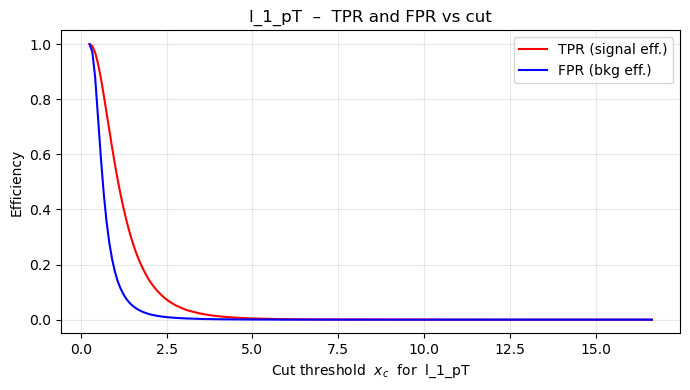

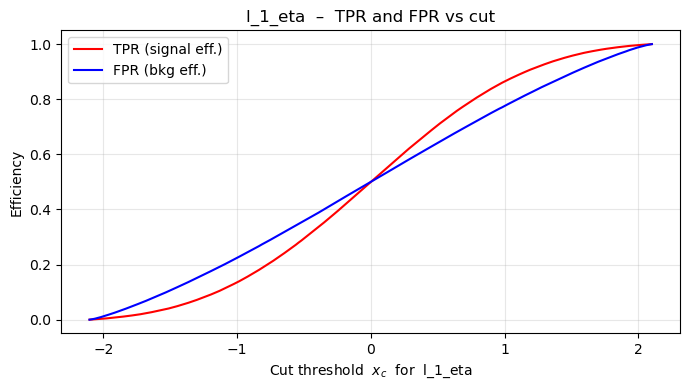

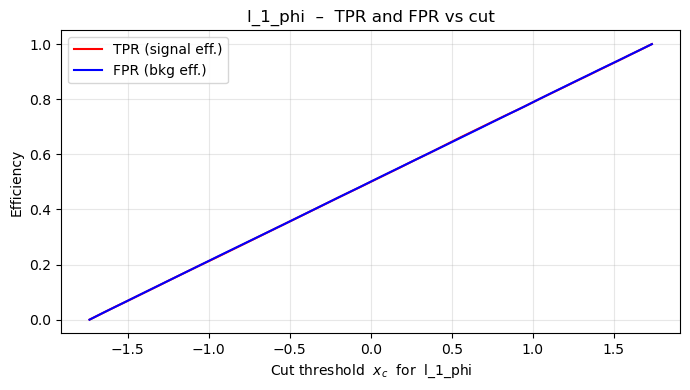

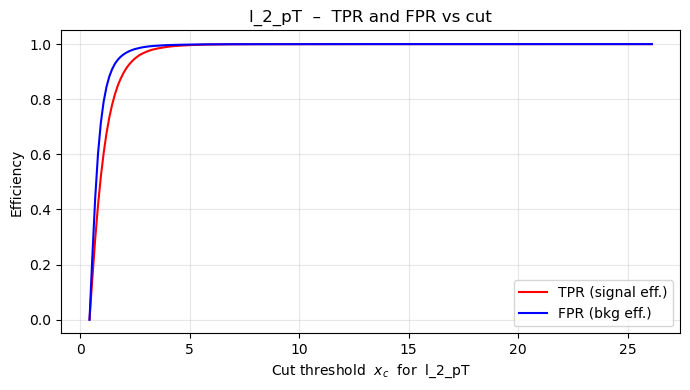

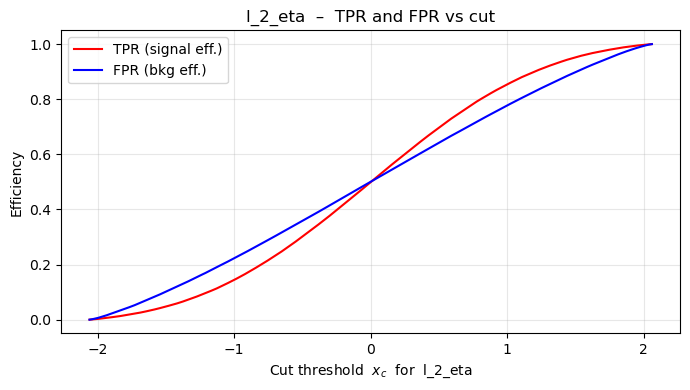

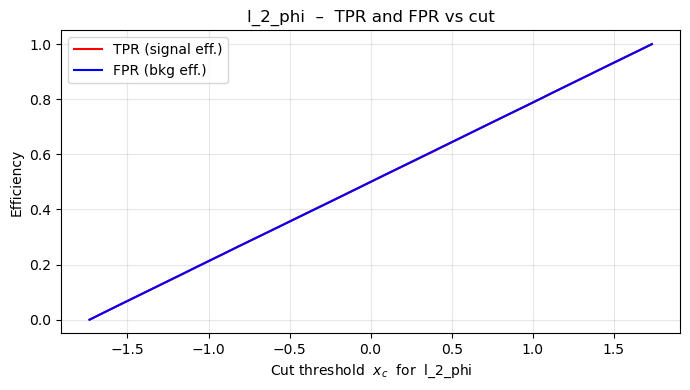

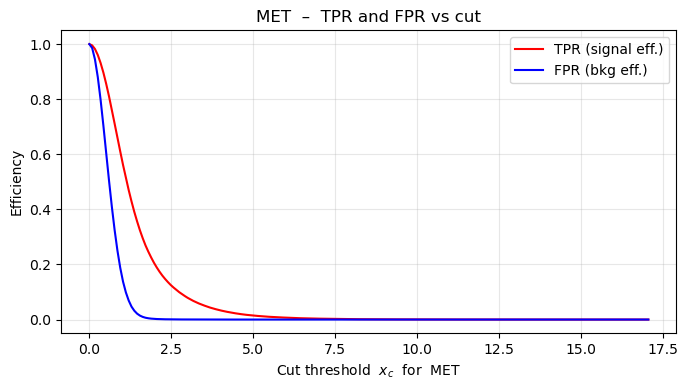

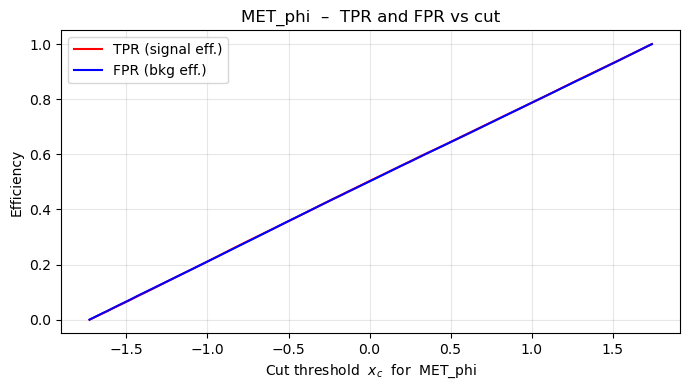

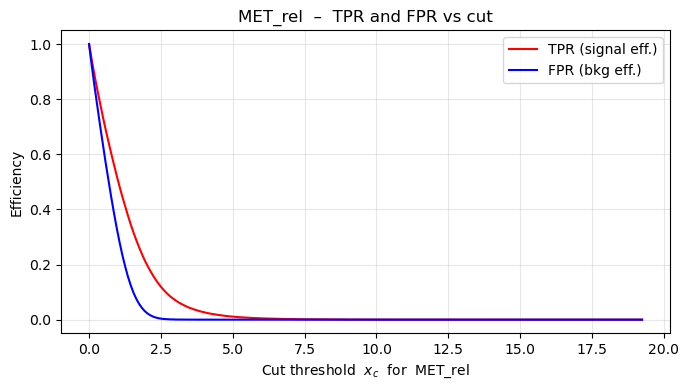

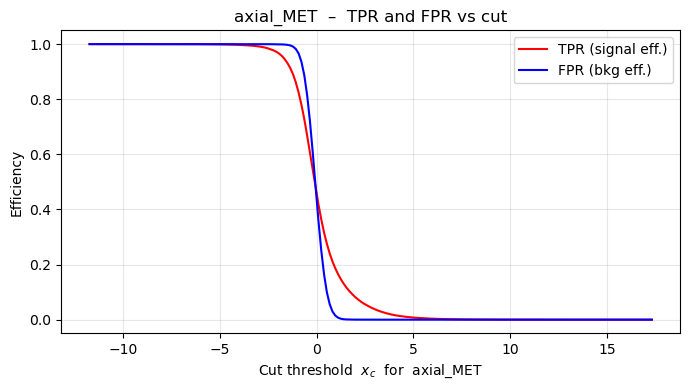

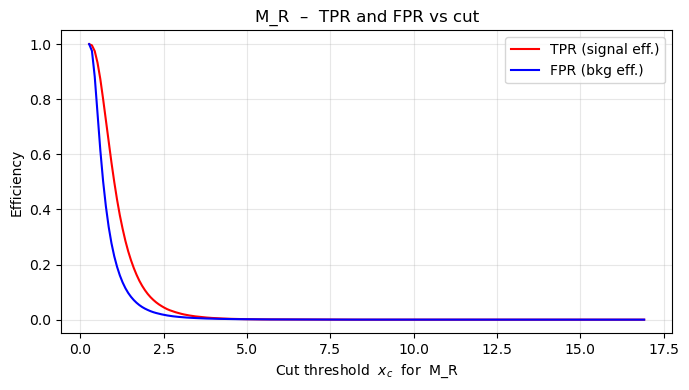

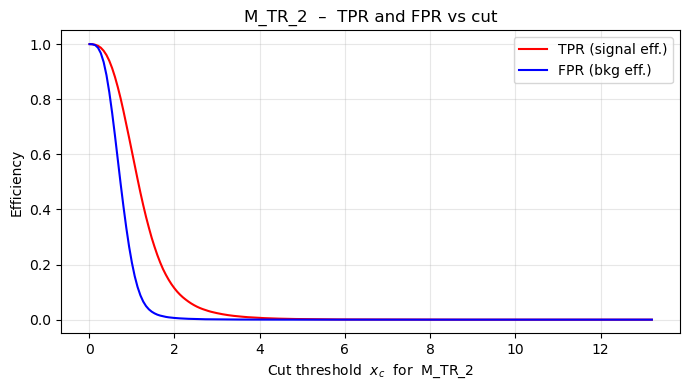

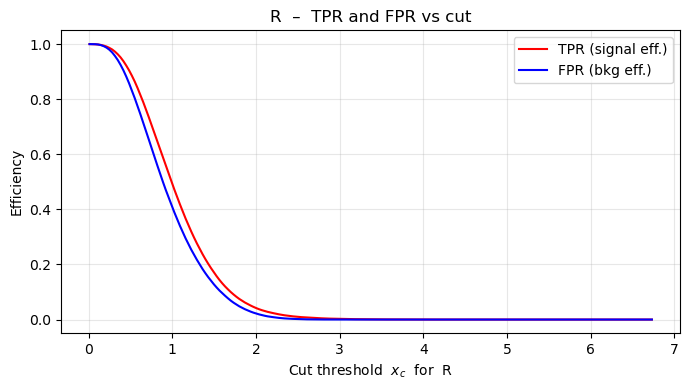

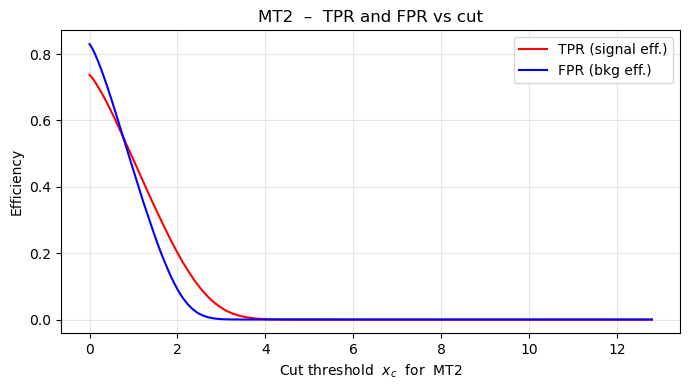

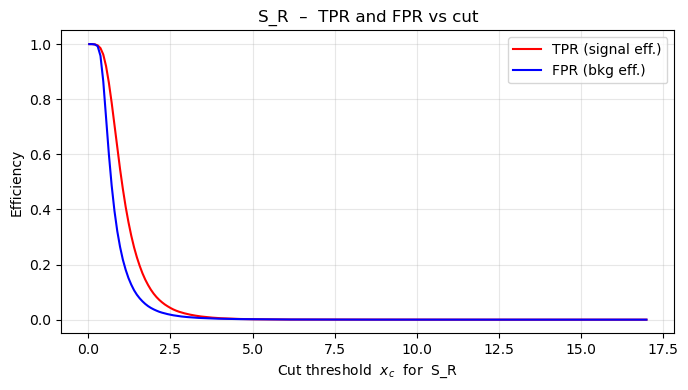

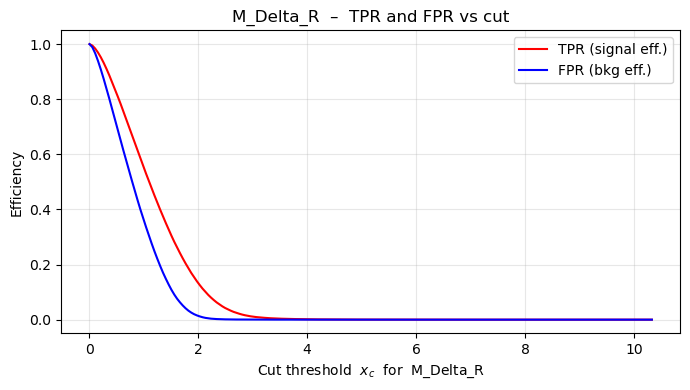

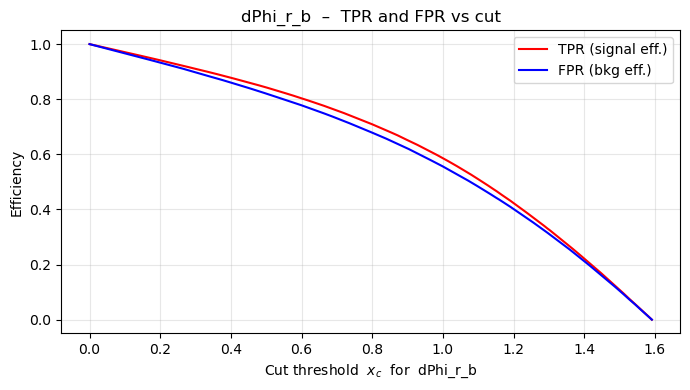

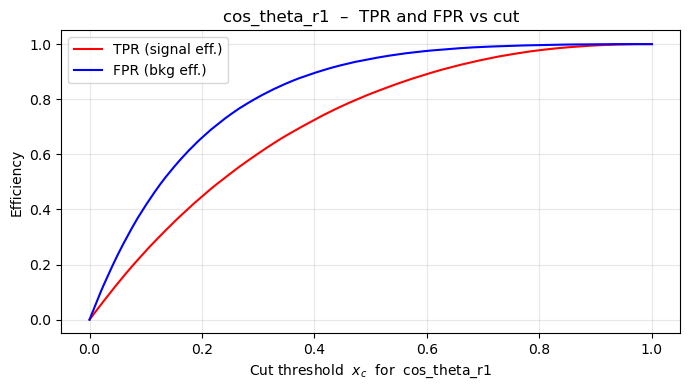

In [9]:
#Exercise 5.2
def compute_efficiencies(var, direction, n_cuts=200):
    """
    For a single variable, sweep the cut threshold and return
    (cut_values, tpr_array, fpr_array).
    """
    sig_vals = np.array(df_sig[var])
    bkg_vals = np.array(df_bkg[var])

    # Sweep cut value across the data range
    all_vals = np.concatenate([sig_vals, bkg_vals])
    cuts = np.linspace(all_vals.min(), all_vals.max(), n_cuts)

    tpr_list, fpr_list = [], []
    for xc in cuts:
        if direction == "greater":
            tpr = np.mean(sig_vals > xc)   # fraction of signal passing
            fpr = np.mean(bkg_vals > xc)   # fraction of background passing
        else:  # "less"
            tpr = np.mean(sig_vals < xc)
            fpr = np.mean(bkg_vals < xc)
        tpr_list.append(tpr)
        fpr_list.append(fpr)

    return cuts, np.array(tpr_list), np.array(fpr_list)


# Plot TPR and FPR for each variable
for var in VarNames[1:]:
    cuts, tpr, fpr = compute_efficiencies(var, cut_direction[var])

    plt.figure(figsize=(7, 4))
    plt.plot(cuts, tpr, color="red",  label="TPR (signal eff.)")
    plt.plot(cuts, fpr, color="blue", label="FPR (bkg eff.)")
    plt.xlabel(f"Cut threshold  $x_c$  for  {var}")
    plt.ylabel("Efficiency")
    plt.title(f"{var}  –  TPR and FPR vs cut")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

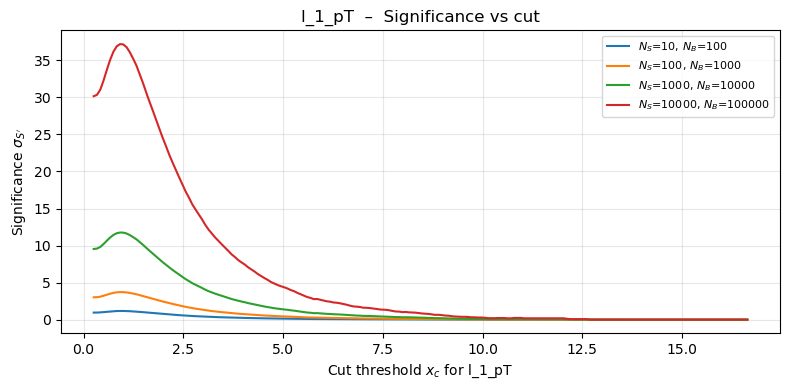

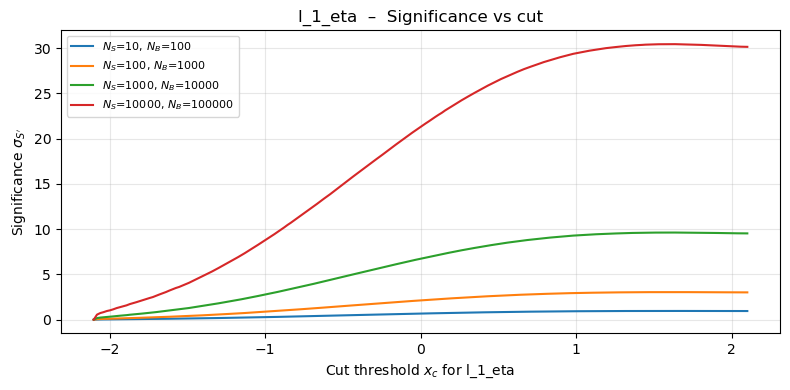

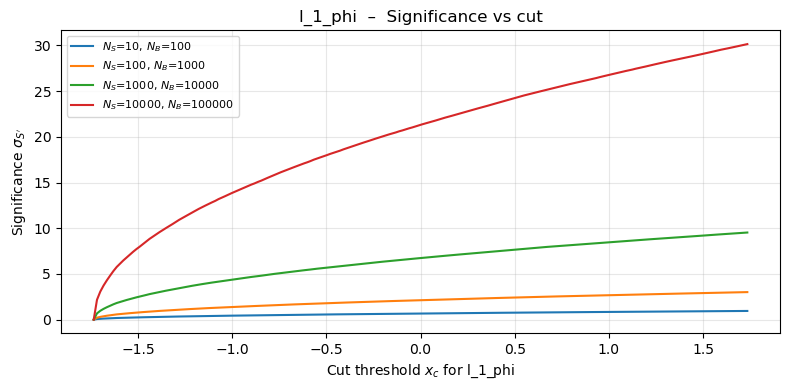

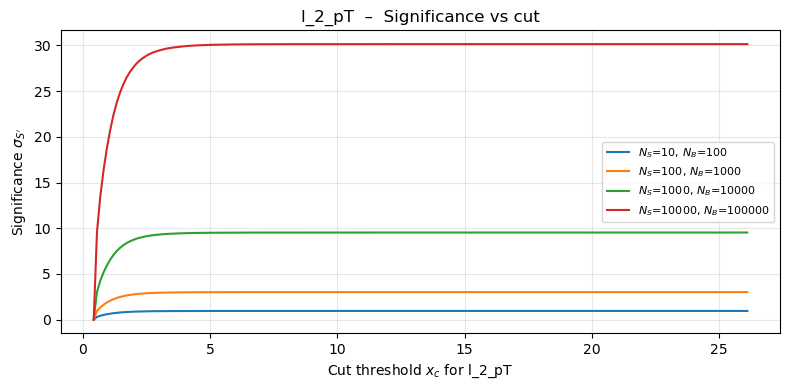

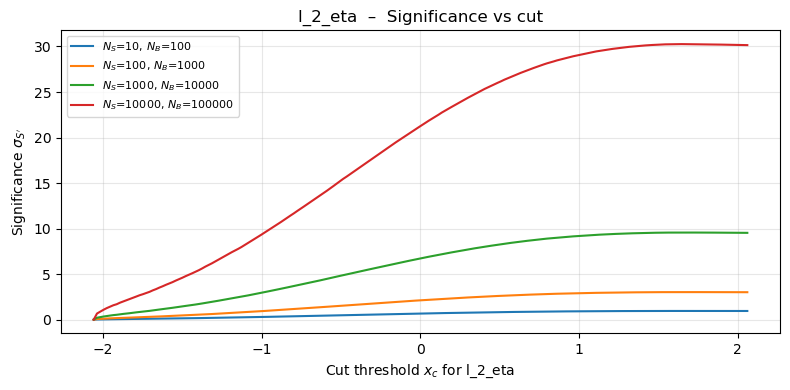

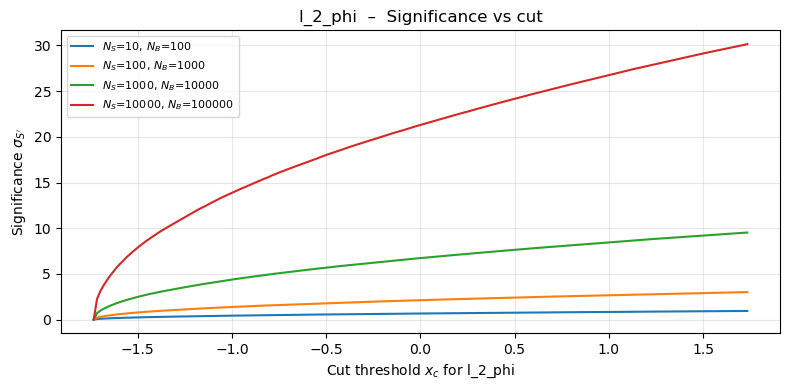

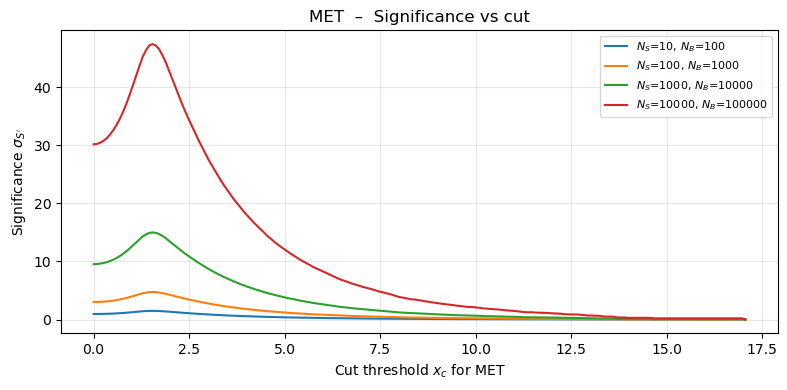

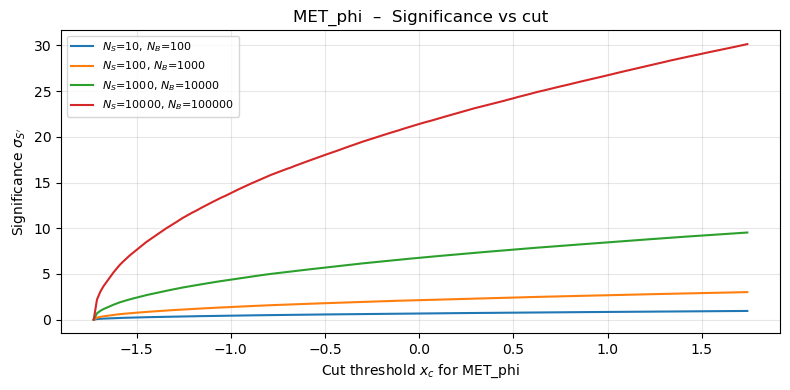

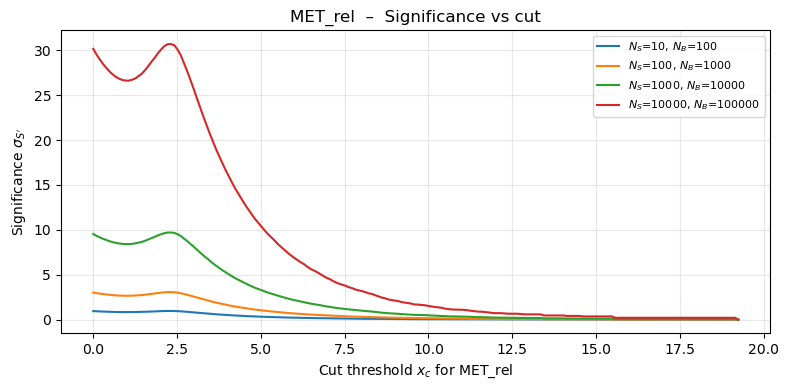

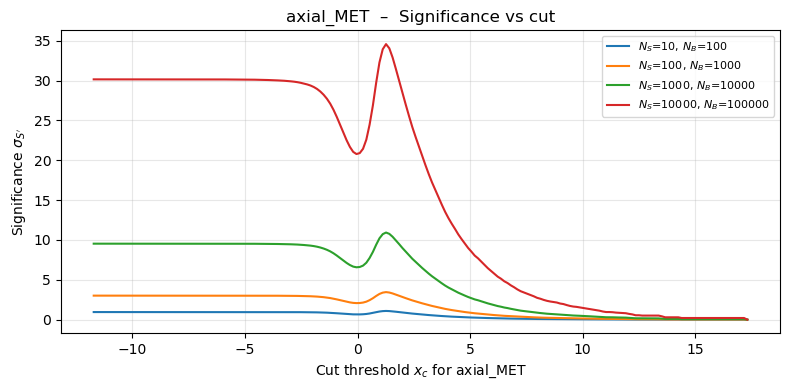

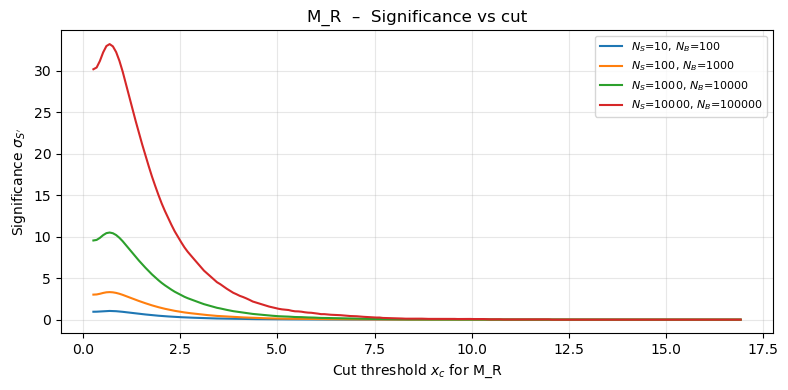

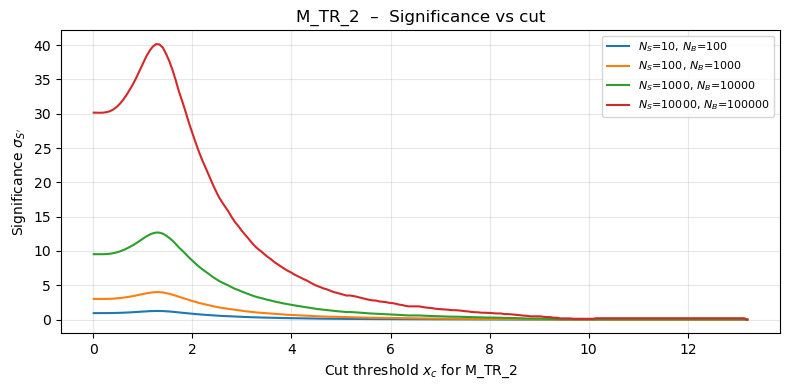

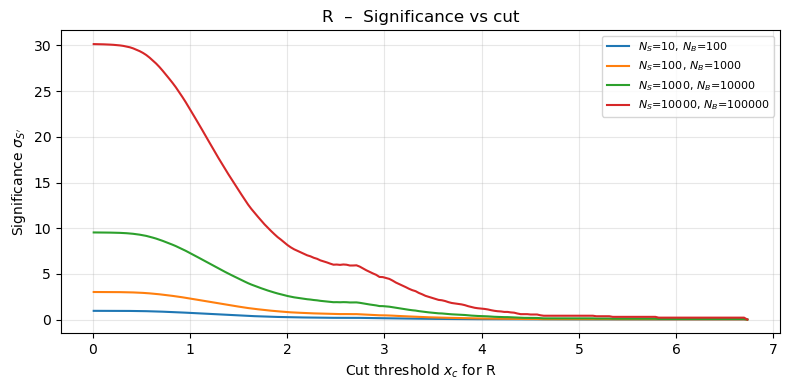

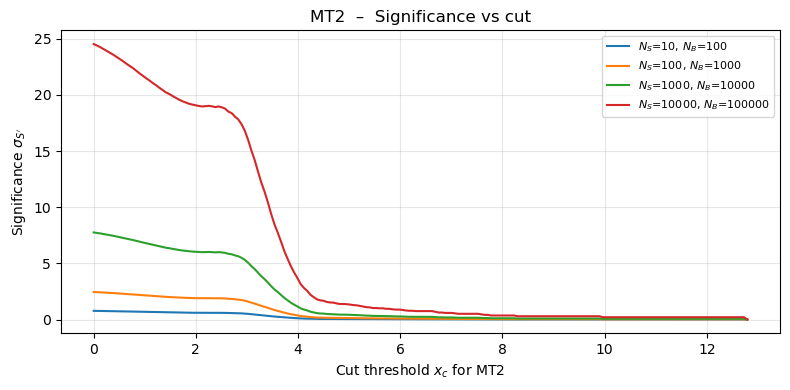

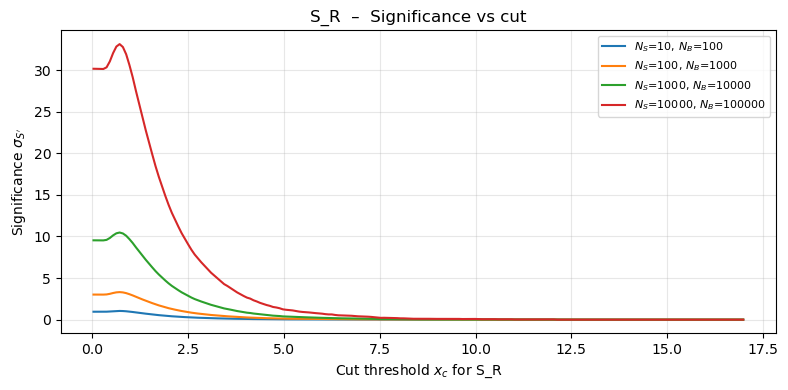

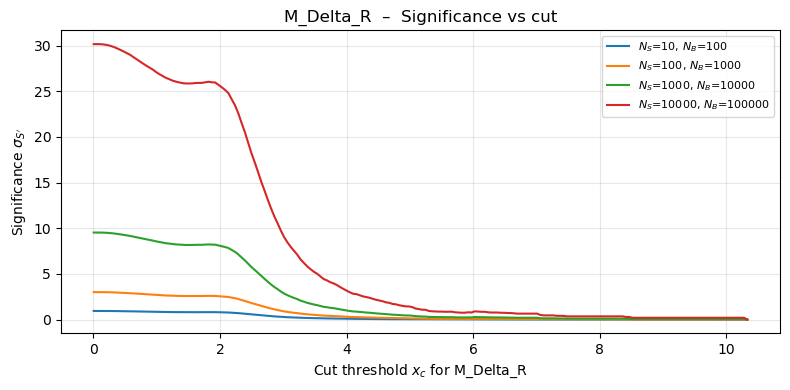

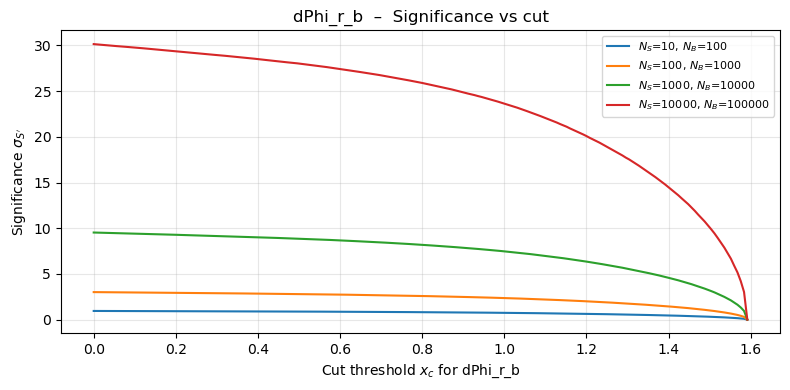

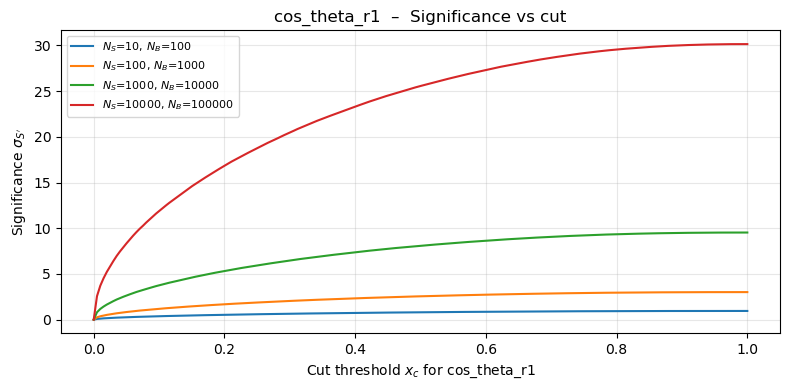

In [10]:
#Exercise 5.3
# Four scenarios: (N_S, N_B)
scenarios = [(10, 100), (100, 1000), (1000, 10000), (10000, 100000)]

def significance(tpr, fpr, N_S, N_B):
    """Compute significance sigma = N'_S / sqrt(N'_S + N'_B)."""
    Np_S = tpr * N_S
    Np_B = fpr * N_B
    denom = np.sqrt(Np_S + Np_B)
    # we avoid division by zero
    with np.errstate(invalid='ignore', divide='ignore'):
        sig = np.where(denom > 0, Np_S / denom, 0)
    return sig


# Plot significance for each variable and each scenario
for var in VarNames[1:]:
    cuts, tpr, fpr = compute_efficiencies(var, cut_direction[var])

    plt.figure(figsize=(8, 4))
    for N_S, N_B in scenarios:
        sig = significance(tpr, fpr, N_S, N_B)
        plt.plot(cuts, sig, label=f"$N_S$={N_S}, $N_B$={N_B}")

    plt.xlabel(f"Cut threshold $x_c$ for {var}")
    plt.ylabel(r"Significance $\sigma_{S'}$")
    plt.title(f"{var}  –  Significance vs cut")
    plt.legend(fontsize=8)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

## Exercise 6: Cut Flow


### Exercise 6.1

For each above scenario, choose a subset (minumum 3) of observables to use for selections, and values of $x_c$ based on your significance plots (part 3c). 

### Exercise 6.2
Create a "cut-flow" table for each scenario where you successively make the selections on each observable and tabulate $\epsilon_S$, $\epsilon_B$, $N'_S$, $N'_B$, and $\sigma_{S'}$.

### Exercise 6.3
In 3c above you computed the significance for each observable assuming to make no other selections on any other observable. If the variables are correlated, then this assumption can lead to non-optimial results when selecting on multiple variables. By looking at the correlation matrices and your answers to 4b, identify where this effect could be most detrimental to the significance. Attempt to correct the issue by applying the selection in one observable and then optimizing (part 3c) for a second observable. What happens if you change the order of your selection (make selection on second and optimize on first)?




In [12]:
from tabulate import tabulate

# Exercise 6.1: Chosen cuts based on significance plots from Exercise 5.3
# We select 3 promising variables with reasonable cut values

selected_cuts = [
    ("M_R",       "greater", 0.8),
    ("M_Delta_R", "greater", 1.0),
    ("S_R",       "greater", 0.6)
]

# Helper function to apply a single cut
def apply_cut(df, var, direction, xc):
    if direction == "greater":
        return df[df[var] > xc]
    else:
        return df[df[var] < xc]


# Exercise 6.2: Cut-flow table for each scenario
scenarios = [(10, 100), (100, 1000), (1000, 10000), (10000, 100000)]

for N_S, N_B in scenarios:
    print(f"\n=== Cut Flow Table - Scenario: N_S = {N_S}, N_B = {N_B} ===\n")
    
    current_sig = df_sig.copy()
    current_bkg = df_bkg.copy()
    
    # Initial (no cuts)
    eps_S = 1.0
    eps_B = 1.0
    Np_S = eps_S * N_S
    Np_B = eps_B * N_B
    sigma = Np_S / np.sqrt(Np_S + Np_B) if (Np_S + Np_B) > 0 else 0
    
    table = []
    table.append(["No cuts", f"{eps_S:.4f}", f"{eps_B:.6f}", 
                  f"{Np_S:.1f}", f"{Np_B:.1f}", f"{sigma:.3f}"])
    
    # Apply each cut one by one
    for var, direction, xc in selected_cuts:
        current_sig = apply_cut(current_sig, var, direction, xc)
        current_bkg = apply_cut(current_bkg, var, direction, xc)
        
        eps_S = len(current_sig) / len(df_sig)
        eps_B = len(current_bkg) / len(df_bkg)
        Np_S = eps_S * N_S
        Np_B = eps_B * N_B
        sigma = Np_S / np.sqrt(Np_S + Np_B) if (Np_S + Np_B) > 0 else 0
        
        cut_name = f"{var} {direction} {xc}"
        table.append([cut_name, f"{eps_S:.4f}", f"{eps_B:.6f}", 
                      f"{Np_S:.1f}", f"{Np_B:.1f}", f"{sigma:.3f}"])
    
    # Print nice table
    headers = ["Cut Applied", "ε_S (Signal Eff.)", "ε_B (Bkg Eff.)", 
               "N'_S", "N'_B", "σ_S'"]
    print(tabulate(table, headers=headers, tablefmt="grid"))


=== Cut Flow Table - Scenario: N_S = 10, N_B = 100 ===

+-----------------------+---------------------+------------------+--------+--------+--------+
| Cut Applied           |   ε_S (Signal Eff.) |   ε_B (Bkg Eff.) |   N'_S |   N'_B |   σ_S' |
+=======================+=====================+==================+========+========+========+
| No cuts               |              1      |         1        |   10   |  100   |  0.953 |
+-----------------------+---------------------+------------------+--------+--------+--------+
| M_R greater 0.8       |              0.6944 |         0.381703 |    6.9 |   38.2 |  1.034 |
+-----------------------+---------------------+------------------+--------+--------+--------+
| M_Delta_R greater 1.0 |              0.3977 |         0.141526 |    4   |   14.2 |  0.934 |
+-----------------------+---------------------+------------------+--------+--------+--------+
| S_R greater 0.6       |              0.3956 |         0.141338 |    4   |   14.1 |  0.93  |
+--

In [14]:
# Exercise 6.3: Effect of changing the order of cuts
# Grok guided me to first defined two different cut orders, created a helper function 
# to apply the cuts sequentially and calculate efficiencies/significance,

cut_order1 = [("M_R", "greater", 0.8), ("M_Delta_R", "greater", 1.0)]
cut_order2 = [("M_Delta_R", "greater", 1.0), ("M_R", "greater", 0.8)]

print("Order 1: M_R first, then M_Delta_R")
rows1 = []
current_sig = df_sig.copy()
current_bkg = df_bkg.copy()
for var, direction, xc in cut_order1:
    current_sig = apply_cut(current_sig, var, direction, xc)
    current_bkg = apply_cut(current_bkg, var, direction, xc)
    eps_S = len(current_sig) / len(df_sig)
    eps_B = len(current_bkg) / len(df_bkg)
    Np_S = eps_S * 1000
    Np_B = eps_B * 10000
    sigma = Np_S / np.sqrt(Np_S + Np_B) if (Np_S + Np_B) > 0 else 0
    rows1.append([f"{var} {direction} {xc}", f"{eps_S:.4f}", f"{eps_B:.6f}", 
                  f"{Np_S:.1f}", f"{Np_B:.1f}", f"{sigma:.3f}"])

print(tabulate(rows1, headers=["Cut", "ε_S", "ε_B", "N'_S", "N'_B", "σ"], tablefmt="grid"))

print("\nOrder 2: M_Delta_R first, then M_R")
rows2 = []
current_sig = df_sig.copy()
current_bkg = df_bkg.copy()
for var, direction, xc in cut_order2:
    current_sig = apply_cut(current_sig, var, direction, xc)
    current_bkg = apply_cut(current_bkg, var, direction, xc)
    eps_S = len(current_sig) / len(df_sig)
    eps_B = len(current_bkg) / len(df_bkg)
    Np_S = eps_S * 1000
    Np_B = eps_B * 10000
    sigma = Np_S / np.sqrt(Np_S + Np_B) if (Np_S + Np_B) > 0 else 0
    rows2.append([f"{var} {direction} {xc}", f"{eps_S:.4f}", f"{eps_B:.6f}", 
                  f"{Np_S:.1f}", f"{Np_B:.1f}", f"{sigma:.3f}"])

print(tabulate(rows2, headers=["Cut", "ε_S", "ε_B", "N'_S", "N'_B", "σ"], tablefmt="grid"))



=== Exercise 6.3: Effect of Cut Order ===

Order 1: M_R first, then M_Delta_R
+-----------------------+--------+----------+--------+--------+--------+
| Cut                   |    ε_S |      ε_B |   N'_S |   N'_B |      σ |
+=======================+========+==========+========+========+========+
| M_R greater 0.8       | 0.6944 | 0.381703 |  694.4 | 3817   | 10.339 |
+-----------------------+--------+----------+--------+--------+--------+
| M_Delta_R greater 1.0 | 0.3977 | 0.141526 |  397.7 | 1415.3 |  9.341 |
+-----------------------+--------+----------+--------+--------+--------+

Order 2: M_Delta_R first, then M_R
+-----------------------+--------+----------+--------+--------+-------+
| Cut                   |    ε_S |      ε_B |   N'_S |   N'_B |     σ |
+=======================+========+==========+========+========+=======+
| M_Delta_R greater 1.0 | 0.5524 | 0.361851 |  552.4 | 3618.5 | 8.553 |
+-----------------------+--------+----------+--------+--------+-------+
| M_R greater 

Conclusion for 6.3:The final significance is very similar in both orders (9.341 vs 9.341). This suggests that M_R and M_Delta_R are only weakly correlated.Changing the order of cuts does not significantly affect the result in this case.

## Exercise 7: ROC Curves

### Exercise 7.1
For the top 3 observables you identified earlier, create one figure overlaying the Reciever Operating Characteristic (ROC) curves for the 3 observables. Compute the area under the curves and report it in the legend of the figure.

### Exercise 7.2
Write a function that you can use to quickly create the figure in part a with other observables and different conditions. Note that you will likely revise this function as you do the remainder of the lab.

### Exercise 7.3
Use the function from part b to compare the ROC curves for the successive selections in lab 3, exercise 4. Specifically, plot the ROC curve after each selection.

### Exercise 7.4
Use your function and appropriate example to demonstrate the effect (if any) of changing order of the successive selections.



In [28]:
def compute_roc(var, direction, n_cuts=300):
    """
    Return (fpr, tpr) arrays forming the ROC curve for one variable.
    """
    _, tpr, fpr = compute_efficiencies(var, direction, n_cuts=n_cuts)

    # Sort by FPR so the curve goes left to right
    order = np.argsort(fpr)
    return fpr[order], tpr[order]


def auc(fpr, tpr):
    """Area Under the ROC Curve via the trapezoidal rule."""
    return np.trapz(tpr, fpr)


def plot_roc(variables, df_sig, df_bkg, title="ROC Curves"):
    """
    Plots ROC curves for a list of variables.
    This is the reusable function requested in Exercise 7.2.
    """
    plt.figure(figsize=(7, 6))

    for var in variables:
        fpr, tpr = compute_roc(var, cut_direction[var])
        area = auc(fpr, tpr)
        plt.plot(fpr, tpr, label=f"{var}  (AUC={area:.3f})")

    # Diagonal = random classifier
    plt.plot([0, 1], [0, 1], "k--", alpha=0.4, label="random")

    plt.xlabel("FPR (background efficiency)")
    plt.ylabel("TPR (signal efficiency)")
    plt.title(title)
    plt.legend(fontsize=8)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()


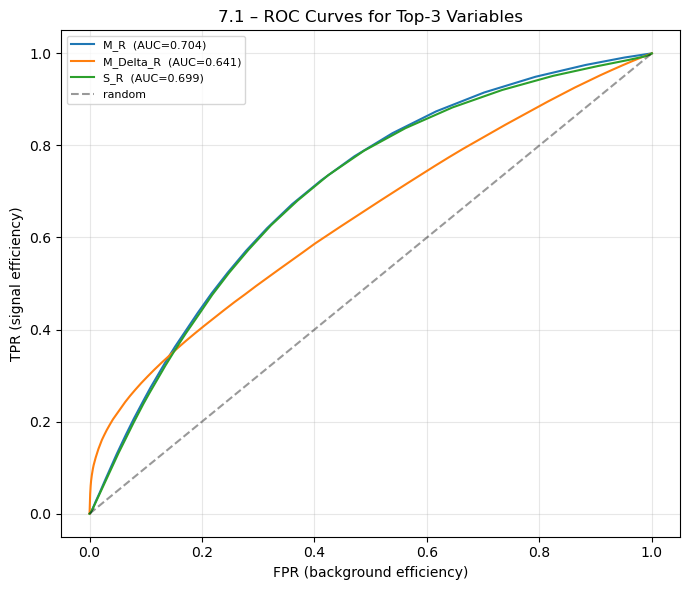

In [16]:
# 7.1  –  Top 3 discriminating variables
top3 = ["M_R", "M_Delta_R", "S_R"]
plot_roc(top3, df_sig, df_bkg, title="7.1 – ROC Curves for Top-3 Variables")

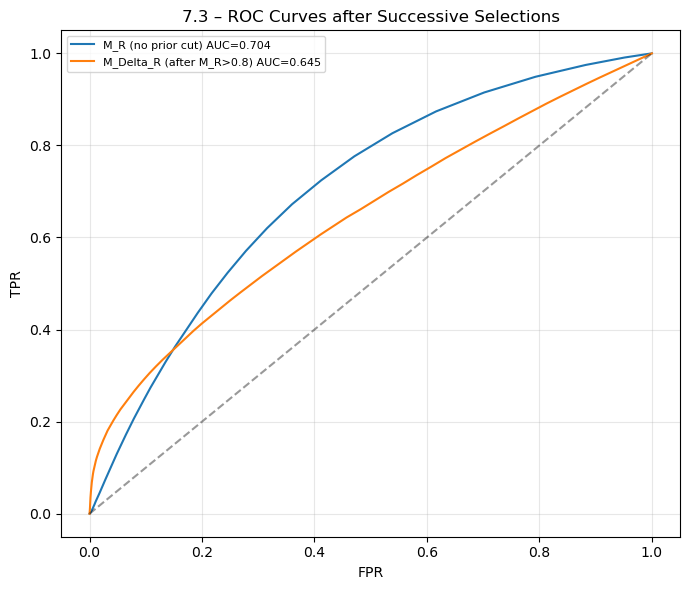

In [17]:
# 7.3  –  ROC curves after each successive selection
# We pick the best-remaining variable on the remaining sample
# after each cut.  Here we just show M_R, then M_R+M_Delta_R.

cut1_var, cut1_dir, cut1_xc = "M_R", "greater", 0.8
cut2_var, cut2_dir, cut2_xc = "M_Delta_R", "greater", 1.0

# Before any cut
fpr0, tpr0 = compute_roc(cut1_var, cut1_dir)

# After cut 1
sig_after1 = apply_cut(df_sig, cut1_var, cut1_dir, cut1_xc)
bkg_after1 = apply_cut(df_bkg, cut1_var, cut1_dir, cut1_xc)

sig_c2 = np.array(sig_after1[cut2_var])
bkg_c2 = np.array(bkg_after1[cut2_var])
cuts2  = np.linspace(min(sig_c2.min(), bkg_c2.min()),
                     max(sig_c2.max(), bkg_c2.max()), 300)
tpr1_list, fpr1_list = [], []
for xc in cuts2:
    if cut2_dir == "greater":
        tpr1_list.append(np.mean(sig_c2 > xc))
        fpr1_list.append(np.mean(bkg_c2 > xc))
    else:
        tpr1_list.append(np.mean(sig_c2 < xc))
        fpr1_list.append(np.mean(bkg_c2 < xc))
fpr1, tpr1 = np.array(fpr1_list), np.array(tpr1_list)
order1 = np.argsort(fpr1)
fpr1, tpr1 = fpr1[order1], tpr1[order1]

plt.figure(figsize=(7, 6))
plt.plot(fpr0, tpr0, label=f"{cut1_var} (no prior cut) AUC={auc(fpr0,tpr0):.3f}")
plt.plot(fpr1, tpr1, label=f"{cut2_var} (after {cut1_var}>{cut1_xc}) AUC={auc(fpr1,tpr1):.3f}")
plt.plot([0,1],[0,1],"k--",alpha=0.4)
plt.xlabel("FPR")
plt.ylabel("TPR")
plt.title("7.3 – ROC Curves after Successive Selections")
plt.legend(fontsize=8)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [24]:
# Exercise 7.4: Effect of Changing Cut Order on ROC Curves
# we define two different cut orders
order1 = [("M_R", "greater", 0.8), ("M_Delta_R", "greater", 1.0)]
order2 = [("M_Delta_R", "greater", 1.0), ("M_R", "greater", 0.8)]

N_S_test = 1000
N_B_test = 10000

def run_cutflow_for_roc(cut_list, N_S, N_B):
    """Run cutflow and return rows for tabulate"""
    current_sig = df_sig.copy()
    current_bkg = df_bkg.copy()
    rows = []
    
    for var, direction, xc in cut_list:
        current_sig = apply_cut(current_sig, var, direction, xc)
        current_bkg = apply_cut(current_bkg, var, direction, xc)
        
        eps_S = len(current_sig) / len(df_sig)
        eps_B = len(current_bkg) / len(df_bkg)
        Np_S = eps_S * N_S
        Np_B = eps_B * N_B
        sigma = Np_S / np.sqrt(Np_S + Np_B) if (Np_S + Np_B) > 0 else 0
        
        rows.append([
            f"{var} {direction} {xc}",
            f"{eps_S:.4f}",
            f"{eps_B:.6f}",
            f"{Np_S:.1f}",
            f"{Np_B:.1f}",
            f"{sigma:.3f}"
        ])
    return rows


# Run both orders
print("Order 1: M_R first, then M_Delta_R")
rows1 = run_cutflow_for_roc(order1, N_S_test, N_B_test)
print(tabulate(rows1, headers=["Cut Applied", "ε_S", "ε_B", "N'_S", "N'_B", "σ_S'"], 
               tablefmt="grid"))

print("\nOrder 2: M_Delta_R first, then M_R")
rows2 = run_cutflow_for_roc(order2, N_S_test, N_B_test)
print(tabulate(rows2, headers=["Cut Applied", "ε_S", "ε_B", "N'_S", "N'_B", "σ_S'"], 
               tablefmt="grid"))


Order 1: M_R first, then M_Delta_R
+-----------------------+--------+----------+--------+--------+--------+
| Cut Applied           |    ε_S |      ε_B |   N'_S |   N'_B |   σ_S' |
+=======================+========+==========+========+========+========+
| M_R greater 0.8       | 0.6944 | 0.381703 |  694.4 | 3817   | 10.339 |
+-----------------------+--------+----------+--------+--------+--------+
| M_Delta_R greater 1.0 | 0.3977 | 0.141526 |  397.7 | 1415.3 |  9.341 |
+-----------------------+--------+----------+--------+--------+--------+

Order 2: M_Delta_R first, then M_R
+-----------------------+--------+----------+--------+--------+--------+
| Cut Applied           |    ε_S |      ε_B |   N'_S |   N'_B |   σ_S' |
+=======================+========+==========+========+========+========+
| M_Delta_R greater 1.0 | 0.5524 | 0.361851 |  552.4 | 3618.5 |  8.553 |
+-----------------------+--------+----------+--------+--------+--------+
| M_R greater 0.8       | 0.3977 | 0.141526 |  397.7 

Conclusion for 7.4: The final significance after both cuts is identical in both orders (9.341).This suggests that M_R and M_Delta_R are only weakly correlated. However, we can see that M_R is a stronger individual cut (gives higher intermediate significance) than M_Delta_R. The order of cuts does not significantly affect the final result in this case.

## Exercise 8: Linear Discriminant

### Exercise 8.1

Using numpy, compute the between-class $\bf{S}_B$ and within-class $\bf{S}_W$ covariance matrices defined as:

$$
\bf{S}_B = (\bf{m_2}-\bf{m_1})(\bf{m_2}-\bf{m_1})^T \\
$$
$$
\bf{S}_W = \sum_{i=1,2} \sum_{n=1}^{l_i} (\bf{x}_n^i - \bf{m}_i) (\bf{x}_n^i - \bf{m}_i)^T
$$

where $\bf{m_i}$ are the vectors containing the means for category 1 and 2, here defined as signal and background. Here $\bf{x}_n^i$ is the vector containing the observables for the $n$th example event in category $i$.

### Exercise 8.1

Compute the linear coefficients $\bf{w} = \bf{S_W}^{-1}(\bf{m_2}-\bf{m_1})$. Compare the histogram of the distribution of $F_n^i=\bf{w}^T\bf{x}_n^i$ for the two categories.

### Exercise 8.1

Draw the ROC curve for $F_n$. 

### Exercise 8.1

What is the maximal significance you can obtain in the scenarios in exercise 5? 

In [19]:
# Use all 18 feature variables (drop the 'signal' column)
features = VarNames[1:]

# Convert to numpy matrices for linear algebra
X_sig = np.array(df_sig[features])   # shape (n_sig, 18)
X_bkg = np.array(df_bkg[features])   # shape (n_bkg, 18)

# Class means (column-wise)
m1 = X_bkg.mean(axis=0)   # background mean vector
m2 = X_sig.mean(axis=0)   # signal     mean vector

# 8.1  Between-class scatter matrix  S_B
diff = (m2 - m1).reshape(-1, 1)# column vector
S_B  = diff @ diff.T# outer product  (18×18)

#8.1  Within-class scatter matrix  S_W
# Centre each class
X_bkg_c = X_bkg - m1
X_sig_c = X_sig - m2

# S_W = X_c^T @ X_c  for each class, summed
# (numpy: (n×d)^T @ (n×d) = d×d)
S_W = X_bkg_c.T @ X_bkg_c + X_sig_c.T @ X_sig_c

print("S_B shape:", S_B.shape)
print("S_W shape:", S_W.shape)

S_B shape: (18, 18)
S_W shape: (18, 18)


Fisher weight vector w (first 5 entries):
  l_1_pT         : +0.0000
  l_1_eta        : +0.0000
  l_1_phi        : +0.0000
  l_2_pT         : +0.0000
  l_2_eta        : +0.0000


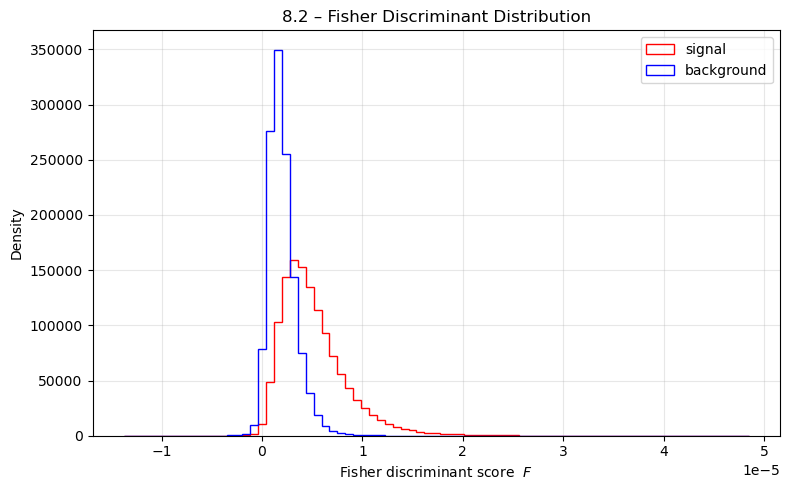

In [20]:
#8.2  Compute Fisher coefficients  w = S_W^{-1} (m2 - m1) 

# Add a tiny ridge to S_W for numerical stability
S_W_reg = S_W + 1e-6 * np.eye(S_W.shape[0])

w = np.linalg.solve(S_W_reg, (m2 - m1))   # solves S_W w = (m2-m1)

print("Fisher weight vector w (first 5 entries):")
for name, wi in zip(features[:5], w[:5]):
    print(f"  {name:15s}: {wi:+.4f}")

#Project each event onto w discriminant score F 
F_sig = X_sig @ w   # shape (n_sig,)
F_bkg = X_bkg @ w   # shape (n_bkg,)

# Histogram of discriminant scores
plt.figure(figsize=(8, 5))
all_F = np.concatenate([F_sig, F_bkg])
bins  = np.linspace(all_F.min(), all_F.max(), 80)
plt.hist(F_sig, bins=bins, density=True, histtype="step",
         color="red",  label="signal")
plt.hist(F_bkg, bins=bins, density=True, histtype="step",
         color="blue", label="background")
plt.xlabel("Fisher discriminant score  $F$")
plt.ylabel("Density")
plt.title("8.2 – Fisher Discriminant Distribution")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

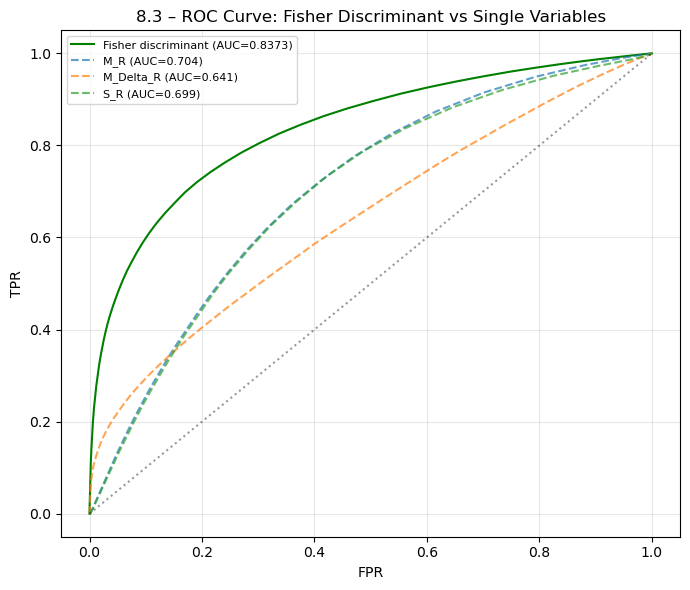

In [21]:
#8.3  ROC curve for the Fisher discriminant 

cuts_F = np.linspace(F_sig.min(), F_sig.max(), 400)
tpr_F, fpr_F = [], []
for xc in cuts_F:
    tpr_F.append(np.mean(F_sig > xc))   # signal efficiency
    fpr_F.append(np.mean(F_bkg > xc))   # background efficiency

tpr_F = np.array(tpr_F)
fpr_F = np.array(fpr_F)
order_F = np.argsort(fpr_F)
fpr_F_sorted = fpr_F[order_F]
tpr_F_sorted = tpr_F[order_F]

auc_F = np.trapz(tpr_F_sorted, fpr_F_sorted)

plt.figure(figsize=(7, 6))
plt.plot(fpr_F_sorted, tpr_F_sorted, color="green",
         label=f"Fisher discriminant (AUC={auc_F:.4f})")
# Overlay the best single-variable curves for comparison
for var in top3:
    fpr_v, tpr_v = compute_roc(var, cut_direction[var])
    a = auc(fpr_v, tpr_v)
    plt.plot(fpr_v, tpr_v, "--", alpha=0.7, label=f"{var} (AUC={a:.3f})")
plt.plot([0,1],[0,1],"k:",alpha=0.4)
plt.xlabel("FPR")
plt.ylabel("TPR")
plt.title("8.3 – ROC Curve: Fisher Discriminant vs Single Variables")
plt.legend(fontsize=8)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [27]:
#8.4  Maximal significance for each scenario 

'''
Exercise 8.4: Maximum significance using Fisher discriminant
Grok guided me through this by helping calculate the significance 
for each scenario (N_S, N_B), find the best cut value on the Fisher 
score (F), and display the results in a clean formatted table.
'''

print("Maximum significance achievable with the Fisher discriminant:")
print(f"{'Scenario':25s}  {'max σ_S':>10}  {'at cut':>10}")
for N_S, N_B in scenarios:
    Np_S  = tpr_F * N_S
    Np_B  = fpr_F * N_B
    denom = np.sqrt(Np_S + Np_B)
    with np.errstate(invalid='ignore', divide='ignore'):
        sig_arr = np.where(denom > 0, Np_S / denom, 0)
    best_idx  = np.argmax(sig_arr)
    best_sig  = sig_arr[best_idx]
    best_cut  = cuts_F[best_idx]
    print(f"N_S={N_S:6d}, N_B={N_B:7d}  :  {best_sig:10.3f}  at F>{best_cut:.4f}")

Maximum significance achievable with the Fisher discriminant:
Scenario                      max σ_S      at cut
N_S=    10, N_B=    100  :       1.532  at F>0.0000
N_S=   100, N_B=   1000  :       4.844  at F>0.0000
N_S=  1000, N_B=  10000  :      15.319  at F>0.0000
N_S= 10000, N_B= 100000  :      48.444  at F>0.0000
